In [3]:
import pandas as pd

data_path = "../Data/"

adv = pd.read_csv(data_path+"Advertising.csv", index_col=0)
adv.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [4]:
import numpy as np
# Y is a response variable
Y = sales = adv['Sales']
# Antag att regression av 'TV' på 'sales' är ungefär linjär
# Y ≈ β0 + β1 X
# sales = 1·β0 + 'TV'· β1 
# Modellspecifikationsmatrisen (designmatrisen) behöver en 1:a i första kolumnen
X = TV = np.column_stack([np.ones(Y.shape[0]), adv['TV']])
X

array([[  1. , 230.1],
       [  1. ,  44.5],
       [  1. ,  17.2],
       [  1. , 151.5],
       [  1. , 180.8],
       [  1. ,   8.7],
       [  1. ,  57.5],
       [  1. , 120.2],
       [  1. ,   8.6],
       [  1. , 199.8],
       [  1. ,  66.1],
       [  1. , 214.7],
       [  1. ,  23.8],
       [  1. ,  97.5],
       [  1. , 204.1],
       [  1. , 195.4],
       [  1. ,  67.8],
       [  1. , 281.4],
       [  1. ,  69.2],
       [  1. , 147.3],
       [  1. , 218.4],
       [  1. , 237.4],
       [  1. ,  13.2],
       [  1. , 228.3],
       [  1. ,  62.3],
       [  1. , 262.9],
       [  1. , 142.9],
       [  1. , 240.1],
       [  1. , 248.8],
       [  1. ,  70.6],
       [  1. , 292.9],
       [  1. , 112.9],
       [  1. ,  97.2],
       [  1. , 265.6],
       [  1. ,  95.7],
       [  1. , 290.7],
       [  1. , 266.9],
       [  1. ,  74.7],
       [  1. ,  43.1],
       [  1. , 228. ],
       [  1. , 202.5],
       [  1. , 177. ],
       [  1. , 293.6],
       [  1

\begin{equation*}
    \boldsymbol{\hat{\beta}} = \mathbf{b} = (X^TX)^{-1}X^T\mathbf{y}.
\end{equation*}

In [5]:
# pseudo-invers
b = np.linalg.pinv(X.T @ X) @ X.T @ Y
b

array([7.03259355, 0.04753664])

Efter regression får vi en skattare för $y$:

$\hat{y} = \beta_0 + \beta_1x$  

Modellen är alltså $\hat{y} = 7.0325 + 0.0475x$

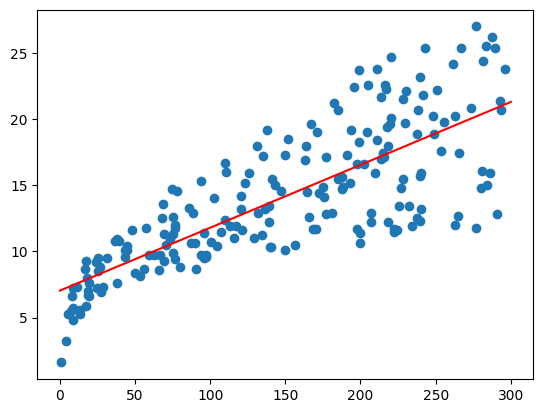

In [6]:
import matplotlib.pyplot as plt 

plt.scatter(X[:, 1], Y)
x = np.linspace(0,300)
y_hat = b[0] + b[1]*x
plt.plot(x, y_hat, c="red")

SSE = (y1 − β̂0 − β̂1 x1 )² + (y2 − β̂0 − β̂1 x2 )² + · · · + (yn − β̂0 − β̂1 xn )² 

In [7]:
# RSS Residual Sum of Squares
# SSE Sum of Square Errors
# Samma sak!
# stickprovets storlek
n = Y.shape[0]
# antalet parametrar, bara TV i detta fall, så 1
v = X.shape[1] - 1

SSE = np.sum(np.square(Y - (X @ b)))

print(np.column_stack([Y, X]))


[[ 22.1   1.  230.1]
 [ 10.4   1.   44.5]
 [  9.3   1.   17.2]
 [ 18.5   1.  151.5]
 [ 12.9   1.  180.8]
 [  7.2   1.    8.7]
 [ 11.8   1.   57.5]
 [ 13.2   1.  120.2]
 [  4.8   1.    8.6]
 [ 10.6   1.  199.8]
 [  8.6   1.   66.1]
 [ 17.4   1.  214.7]
 [  9.2   1.   23.8]
 [  9.7   1.   97.5]
 [ 19.    1.  204.1]
 [ 22.4   1.  195.4]
 [ 12.5   1.   67.8]
 [ 24.4   1.  281.4]
 [ 11.3   1.   69.2]
 [ 14.6   1.  147.3]
 [ 18.    1.  218.4]
 [ 12.5   1.  237.4]
 [  5.6   1.   13.2]
 [ 15.5   1.  228.3]
 [  9.7   1.   62.3]
 [ 12.    1.  262.9]
 [ 15.    1.  142.9]
 [ 15.9   1.  240.1]
 [ 18.9   1.  248.8]
 [ 10.5   1.   70.6]
 [ 21.4   1.  292.9]
 [ 11.9   1.  112.9]
 [  9.6   1.   97.2]
 [ 17.4   1.  265.6]
 [  9.5   1.   95.7]
 [ 12.8   1.  290.7]
 [ 25.4   1.  266.9]
 [ 14.7   1.   74.7]
 [ 10.1   1.   43.1]
 [ 21.5   1.  228. ]
 [ 16.6   1.  202.5]
 [ 17.1   1.  177. ]
 [ 20.7   1.  293.6]
 [ 12.9   1.  206.9]
 [  8.5   1.   25.1]
 [ 14.9   1.  175.1]
 [ 10.6   1.   89.7]
 [ 23.2   1. 

$\texttt{Cov}(X, Y) = E[(X-\mu_X)(Y-\mu_Y)] = E[XY] - E[X]E[Y]$

$S_{xy} \rightarrow \sum{(X-\mu_X)(Y-\mu_Y)}$

Om X och Y är oberoende så är Cov(X, Y) = 0, men vi kan inte anta det omvända. Dvs Cov=0 betyder inte nödvändigtvis att X och Y är oberoende, men de är åtminstone inte linjärt beroende.

En starkare egenskap är korrelation (Pearson coefficient of correlation), som är ett värde mellan -1 och 1 (inklusive ändpunkterna). 

Låt $X$ och $Y$ vara slumpvariabler med medel $\mu_X$ respektive $\mu_Y$ samt varianser $\sigma_X^2$ och $\sigma_Y^2$.
Korrelationen mellan $X$ och $Y$ ges då av:

\begin{equation*}
\rho_{XY} = \frac{\texttt{Cov(X, Y)}}{\sqrt{(\texttt{Var} X)(\texttt{Var} Y)}}
\end{equation*}

Om Pearsonkoefficienten är 1 eller -1 ($|\rho_{XY}| = 1$) då har vi visat att det finns en ekvation:
$Y = \beta_0 + \beta_1X$ 

Standardfel (kring medlet):

\begin{equation*}
\frac{\sigma^2}{n}
\end{equation*}

In [8]:
X.shape,Y.shape 

((200, 2), (200,))

In [9]:
var = SSE/(n-v-1)

S = np.sqrt(var) # residual standard error, alltså en uppskattning av standardfelet/ stickprovsavvikelsen
# Sum of Squares Regression
SSR = np.sum(b*(X.T @ Y)) - (np.square(np.sum(Y))/n)
Syy = (n*np.sum(np.square(Y)) - np.square(np.sum(Y)))/n
Sxx = (n*np.sum(np.square(X)) - np.square(np.sum(X)))/n

Sxy = (n*np.sum(X[:, 1]@Y) - (np.sum(X[:, 1])*np.sum(Y)))/n


Ok, så regressionen är relevant, men hur bra är den?

\begin{equation*}
\hat{\rho} = r = \frac{S_{xy}}{\sqrt{S_{xx}S_{yy}}}
\end{equation*}

In [10]:
import scipy.stats as stats
rho = Sxy / (np.sqrt(Sxx*Syy))
Rsq = SSR/Syy
r = stats.pearsonr(X[:, 1], Y)
print(f"scipy.stats pearsonnr objekt: {r}")
print(f"scipy.stats korrelation: {r.correlation}\nsqrt(R²):\t\t {np.sqrt(Rsq)}\nR²:\t\t\t {Rsq}\nAlternativ R²: \t\t {1 - (SSE/Syy)}\nr²:                      {np.square(r.correlation)}\nBeräkning av r och R² i flera steg: {rho}, {rho**2}")


scipy.stats pearsonnr objekt: PearsonRResult(statistic=np.float64(0.7822244248616067), pvalue=np.float64(1.467389700194602e-42))
scipy.stats korrelation: 0.7822244248616067
sqrt(R²):		 0.782224424861632
R²:			 0.6118750508501111
Alternativ R²: 		 0.611875050850071
r²:                      0.6118750508500714
Beräkning av r och R² i flera steg: 0.7983953520754693, 0.6374351382157126
